# Customer Segmentation & Marketing Campaign Analytics
## Phase 1 — Data Understanding & Cleaning (SQL-first)

**The business question.** At Postal Savings Bank of China I ran 14 consumer-finance marketing
campaigns. A campaign only works if it reaches the right customers: call everyone and you waste
time and annoy people; call too narrowly and you miss good prospects. This project asks: *can we
group customers into segments that predict how likely each is to respond, using only SQL and
clustering, no black-box model required?*

**What this notebook does (Phase 1 only).** Before segmenting anyone, understand what is actually
in the data and settle every cleaning decision, the same discipline as Project 1. Unlike Project 1's
dataset, this one has no blank cells and no impossible values like an age of 0. Its main
data-quality question is different: **should the literal text "unknown" be treated as a missing
value to fix, or as a real category to keep?** This notebook answers that with numbers, then
builds a clean table other notebooks will reuse.

**SQL-first.** Every query here is a real, standalone `.sql` file in `sql/`, not a query typed
into a notebook cell. `src/db.py` is a small helper that opens the shared DuckDB database and
runs those files, so the SQL itself is written once.

**Dataset.** The UCI *Bank Marketing* dataset: 45,211 phone contacts from a Portuguese bank
selling term deposits. The target, `y`, is whether the customer subscribed.

In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.db import connect, load_raw, run_sql_file, exec_sql_file

pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")

con = connect()
n_rows = load_raw(con)
print(f"Loaded bank_raw: {n_rows:,} rows")
con.execute("DESCRIBE bank_raw").fetchdf()

Loaded bank_raw: 45,211 rows


,column_name,column_type,null,key,default,extra
0,age,BIGINT,YES,None,None,None
1,job,VARCHAR,YES,None,None,None
2,marital,VARCHAR,YES,None,None,None
3,education,VARCHAR,YES,None,None,None
4,default,VARCHAR,YES,None,None,None
5,balance,BIGINT,YES,None,None,None
6,housing,VARCHAR,YES,None,None,None
7,loan,VARCHAR,YES,None,None,None
8,contact,VARCHAR,YES,None,None,None
9,day,BIGINT,YES,None,None,None


## 1. Row count and target balance

`sql/01_row_count_and_target_balance.sql` counts the rows and the subscription rate in one query.

In [2]:
run_sql_file(con, "01_row_count_and_target_balance.sql")

,n_contacts,n_subscribed,subscribe_rate_pct
0,45211,5289,11.7


**What this shows.** 45,211 contacts, matching the dataset's documented size of "~45,000" contacts. **11.7% subscribed.** That's
imbalanced, though less extreme than Project 1's 6.7% default rate. It matters here for a
different reason than in Project 1: we aren't building a classifier, but every segment's response
rate is itself an average of mostly-zeros, so a small segment's response rate is noisier than a
large segment's. Segment sizes will need to be kept in view alongside their response rates, not
read off in isolation.

## 2. Where does the data use "unknown"?

This file has no blank cells. Four categorical columns instead use the literal text `"unknown"` as
one of their own values. `sql/02_unknown_value_counts.sql` finds all four and how common each is.

In [3]:
run_sql_file(con, "02_unknown_value_counts.sql")

,column_name,n_unknown,pct_unknown
0,poutcome,36959,81.75
1,contact,13020,28.80
2,education,1857,4.11
3,job,288,0.64


**What this shows.** `poutcome` (outcome of a previous campaign) is "unknown" for **82%** of
customers, `contact` (how they were reached) for **29%**, `education` for **4%**, and `job` for
under **1%**. Those first two are too common to be a rare data-entry slip; there must be a
structural reason. Sections 5 and 6 investigate before deciding what to do about them.

## 3. Duplicate rows

`sql/03_duplicate_rows.sql` checks whether any two contacts are identical across all 17 columns.

In [4]:
run_sql_file(con, "03_duplicate_rows.sql")

,n_duplicate_rows
0,0


**Zero duplicates.** Nothing to clean here.

## 4. Numeric columns: range and typical value

`sql/04_numeric_column_summary.sql` reports the minimum, median, 99th percentile and maximum of
every numeric column, the same kind of check Project 1 used to catch an age of 0.

In [5]:
run_sql_file(con, "04_numeric_column_summary.sql")

,column_name,min_value,median_value,p99_value,max_value
0,age,18,39.0,71.0,95
1,balance,-8019,448.0,13164.9,102127
2,campaign,1,2.0,16.0,63
3,pdays,-1,-1.0,370.0,871
4,previous,0,0.0,8.9,275
5,"duration (excluded from modeling, shown for co...",0,180.0,1269.0,4918


**What this shows, column by column.**

- **`age`**: 18 to 95, median 39. Every value is a plausible human age; nothing to fix.
- **`balance`**: -8,019 to 102,127 euros, median 448. Negative balances are real (an overdraft),
  not an error, so they stay as they are.
- **`campaign`** (contacts made this campaign): typically 1-2, but stretches up to 63. A tail
  that long can pull a clustering algorithm toward the handful of extreme rows rather than the
  bulk of customers. This is worth capping, but capping is a *feature-engineering* choice made
  for the clustering algorithm's benefit, not a *data-quality fix* — it happens in Phase 3, not
  here, the same separation Project 1 made between cleaning (Phase 1) and scaling (Phase 4).
- **`pdays`** (days since a prior campaign contact): median **-1**. That is not a real day count;
  it is documented as a placeholder for "never contacted before". Section 5 checks this lines up
  with the other columns.
- **`previous`** (prior contacts): typically 0, up to 275. That maximum looks extreme; a spot
  check (not shown here) finds it belongs to a customer with a long, consistent contact history
  (`pdays` = 262, one prior outcome recorded) rather than a garbled record. Left as is for now,
  flagged for the same capping decision as `campaign` in Phase 3.
- **`duration`**: shown only for completeness. As Section 3 of `data/README.md` explains, it is
  known only after a call ends, so it cannot inform who to call, and it will not appear in the
  cleaned table at all.

## 5. Does "never contacted before" mean the same thing everywhere?

Three columns could each describe "this is a first-time contact": `pdays = -1`, `previous = 0`,
and `poutcome = 'unknown'`. `sql/05_never_contacted_before_check.sql` checks whether they agree.

In [6]:
run_sql_file(con, "05_never_contacted_before_check.sql")

,never_contacted_before,n_customers,min_previous,max_previous,n_poutcome_unknown
0,False,8257,1,275,5
1,True,36954,0,0,36954


**What this shows.** `pdays = -1` lines up with `previous = 0` **exactly**: every customer with
one has the other, no exceptions. It very nearly lines up with `poutcome = 'unknown'` too: 36,954
customers have `pdays = -1`, and 36,954 of those (all of them) show `poutcome = 'unknown'`. Only 5
customers, out of 45,211, have `poutcome = 'unknown'` despite having been contacted before — a
tiny inconsistency in the source data (0.01% of rows), not worth acting on.

**Conclusion: `poutcome = 'unknown'` mostly just means "this is this customer's first contact",
not "we don't know something we should know".** That reframes Section 2's finding: an 82% rate of
"unknown" isn't a data-quality problem to fix, it is the honest shape of the customer base — most
of these 45,211 people are being reached for the first time.

## 6. Is "unknown" informative, or just noise?

If "unknown" rows behave just like an average customer, it is safe to treat as a meaningless
placeholder. If they behave very differently, it is a real signal and inventing a replacement
value would erase it. `sql/06_unknown_is_informative.sql` compares each column's "unknown"
subscription rate against the 11.7% overall average.

In [7]:
run_sql_file(con, "06_unknown_is_informative.sql")

,column_name,n_unknown,unknown_subscribe_rate_pct,overall_subscribe_rate_pct
0,contact,13020,4.07,11.7
1,education,1857,13.57,11.7
2,job,288,11.81,11.7
3,poutcome,36959,9.16,11.7


**What this shows.**

- **`contact` unknown → 4.1% subscribe**, well under the 11.7% average (and under both
  known categories: cellular reaches 14.9%, telephone 13.4%). Strongly informative.
- **`poutcome` unknown → 9.2% subscribe**, below average, consistent with Section 5: these are
  first-time contacts, who convert somewhat less often than people being followed up with again.
  Informative, and already explained.
- **`education` unknown → 13.6% subscribe**, a little *above* average. Mildly informative, but
  the category is small (4%) and the direction doesn't obviously point to a stand-in value.
- **`job` unknown → 11.8% subscribe**, essentially identical to the 11.7% average, and the
  smallest category (0.6%). No signal either way.

**Decision: keep "unknown" as its own category in all four columns. Do not impute any of them.**
For `contact` and `poutcome`, "unknown" is a meaningful state with its own behavior, not a gap —
replacing it with a guess would delete a real finding. For `education` and `job`, the categories
are small and close to average, so guessing a replacement risks inventing data for no real gain,
the same principle Project 1 used to decide against guessing a borrower's age. This also keeps the
rule simple and consistent across all four columns rather than picking a different treatment for
each one.

**This is a judgment call**, made on the balance of evidence above rather than a rule with one
obviously correct answer.

## 7. Building the clean table

`sql/07_create_clean_table.sql` applies every decision above in one script and creates
`bank_clean`:
- `job`, `education`, `contact`, `poutcome`: unchanged, "unknown" kept as a category.
- `default`, `housing`, `loan`, `y` (all yes/no text): converted to plain boolean flags and
  renamed to `credit_in_default`, `has_housing_loan`, `has_personal_loan`, `subscribed` — so the
  meaning of a column doesn't require the data dictionary open next to it.
- `contacted_before` (new): `pdays != -1`, so "first-time contact" doesn't have to be remembered
  as a special number every time `pdays` is used.
- `customer_id` (new): a row number, standing in for the customer ID this file doesn't ship with.
- `duration`: **left out entirely.** It stays queryable in `bank_raw` only, for a clearly labeled,
  descriptive footnote, never for segmentation.

In [8]:
exec_sql_file(con, "07_create_clean_table.sql")
preview = con.execute("SELECT * FROM bank_clean LIMIT 5").fetchdf()
preview

,customer_id,age,job,marital,education,credit_in_default,balance,has_housing_loan,has_personal_loan,contact,day,month,campaign,pdays,contacted_before,previous,poutcome,subscribed
0,1,58,management,married,tertiary,False,2143,True,False,unknown,5,may,1,-1,False,0,unknown,False
1,2,44,technician,single,secondary,False,29,True,False,unknown,5,may,1,-1,False,0,unknown,False
2,3,33,entrepreneur,married,secondary,False,2,True,True,unknown,5,may,1,-1,False,0,unknown,False
3,4,47,blue-collar,married,unknown,False,1506,True,False,unknown,5,may,1,-1,False,0,unknown,False
4,5,33,unknown,single,unknown,False,1,False,False,unknown,5,may,1,-1,False,0,unknown,False


In [9]:
n_clean = con.execute("SELECT COUNT(*) FROM bank_clean").fetchone()[0]
n_cols = con.execute("SELECT COUNT(*) FROM (DESCRIBE bank_clean)").fetchone()[0]
print(f"bank_clean: {n_clean:,} rows, {n_cols} columns (bank_raw's 17, minus duration, plus customer_id and contacted_before)")
con.execute("DESCRIBE bank_clean").fetchdf()

bank_clean: 45,211 rows, 18 columns (bank_raw's 17, minus duration, plus customer_id and contacted_before)


,column_name,column_type,null,key,default,extra
0,customer_id,BIGINT,YES,None,None,None
1,age,BIGINT,YES,None,None,None
2,job,VARCHAR,YES,None,None,None
3,marital,VARCHAR,YES,None,None,None
4,education,VARCHAR,YES,None,None,None
5,credit_in_default,BOOLEAN,YES,None,None,None
6,balance,BIGINT,YES,None,None,None
7,has_housing_loan,BOOLEAN,YES,None,None,None
8,has_personal_loan,BOOLEAN,YES,None,None,None
9,contact,VARCHAR,YES,None,None,None


## 8. A quick visual sanity check

Two of this notebook's findings, as charts: the "unknown" categories' subscription rates, and how
rare a *second or later* contact with a customer actually is.

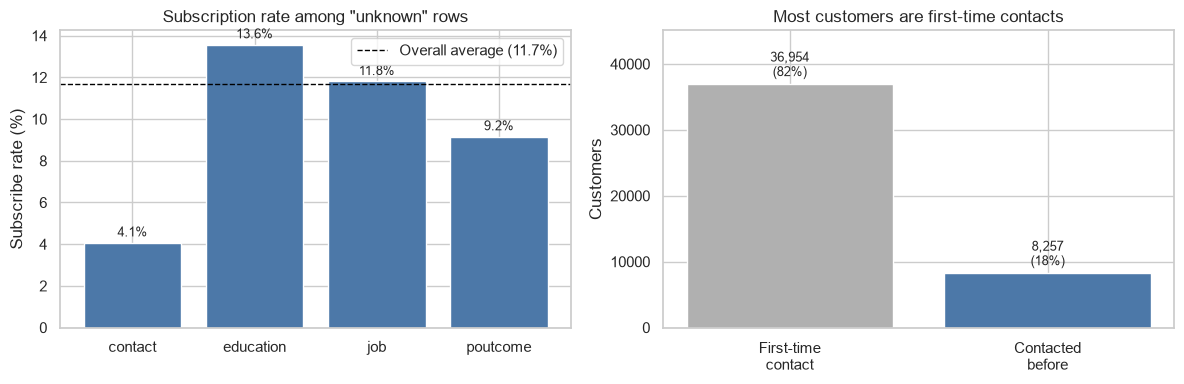

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

unk = run_sql_file(con, "06_unknown_is_informative.sql")
axes[0].bar(unk.column_name, unk.unknown_subscribe_rate_pct, color="#4C78A8")
axes[0].axhline(11.7, color="black", ls="--", lw=1, label="Overall average (11.7%)")
for i, v in enumerate(unk.unknown_subscribe_rate_pct):
    axes[0].text(i, v + 0.3, f"{v:.1f}%", ha="center", fontsize=9)
axes[0].set_title('Subscription rate among "unknown" rows')
axes[0].set_ylabel("Subscribe rate (%)")
axes[0].legend()

contacted = con.execute("SELECT contacted_before, COUNT(*) AS n FROM bank_clean GROUP BY 1 ORDER BY 1").fetchdf()
contacted["label"] = contacted.contacted_before.map({False: "First-time\ncontact", True: "Contacted\nbefore"})
axes[1].bar(contacted.label, contacted.n, color=["#B0B0B0", "#4C78A8"])
axes[1].set_ylim(0, contacted.n.max() * 1.22)
for i, v in enumerate(contacted.n):
    axes[1].text(i, v + 1200, f"{v:,}\n({v/contacted.n.sum():.0%})", ha="center", fontsize=9)
axes[1].set_title("Most customers are first-time contacts")
axes[1].margins(y=0.15)
axes[1].set_ylabel("Customers")

plt.tight_layout()
plt.savefig("../reports/01_unknown_and_contact_history.png", dpi=150)
plt.show()

## Phase 1 summary (plain English)

- **The data is largely clean already.** No blank cells, no duplicate rows, no impossible values
  like Project 1's age of 0. The main decision here was not "how do I fix broken values" but
  "what does this dataset's specific placeholder, `unknown`, actually mean".
- **`unknown` is not one thing.** For `contact` and `poutcome` it is structural and meaningful
  (mostly "first-time contact"), and it is kept as its own category everywhere for consistency and
  because none of the four columns showed a good reason to guess a replacement.
- **82% of customers are first-time contacts** (`pdays = -1`, `previous = 0`,
  `poutcome = 'unknown'`, all three agreeing). Only 8,257 customers (18%) have any prior campaign
  history at all. That imbalance will matter for segmentation in Phase 3: recency and frequency
  features will be near-constant for most of the file and only vary within that smaller 18%.
- **`duration` is excluded from `bank_clean`** entirely, per the leakage warning in
  `data/README.md`.
- **Two numeric columns (`campaign`, `previous`) have long tails** that are real but extreme.
  Whether and how to cap them is deferred to Phase 3, where it belongs alongside the clustering
  feature choices.
- Everything downstream (Phases 2 onward) reads from `bank_clean` in `bank_marketing.duckdb`,
  which this notebook (re)builds from scratch every time it runs.

### The judgment call made in this phase
**Keep "unknown" as its own category in `job`, `education`, `contact` and `poutcome`, with no
imputation**, based on the evidence in Sections 5-6: `poutcome`'s and `contact`'s "unknown" rows
behave clearly differently from the rest (so replacing them would erase a finding), while `job`'s
and `education`'s are small and close to average (so replacing them would risk inventing data for
little gain).